# Volcano plots

In [2]:
import pandas as pd
import scanpy as sc
import decoupler as dc

# Only needed for processing
import numpy as np
import pandas as pd
from anndata import AnnData
import yaml

In [3]:
dds_files_path = '../data/dds_files.yml'

In [4]:
yo_file = "../data/RNAseq_abundances_adjusted_combat_inmose_young.vs.old_DDS.csv"
ym_file = "../data/RNAseq_abundances_adjusted_combat_inmose_young.vs.middle_DDS.csv"
mo_file = "../data/RNAseq_abundances_adjusted_combat_inmose_middle.vs.old_DDS.csv"

In [12]:
with open(dds_files_path, 'r') as file:
    dds_dict = yaml.safe_load(file)

In [13]:
df_dds_dict = {}
for dds, file in dds_dict.items():
    df_dds_dict[dds] =  pd.read_csv(file, index_col=0)

In [3]:
yo_df = pd.read_csv(yo_file, index_col=0)
ym_df = pd.read_csv(ym_file, index_col=0)
mo_df = pd.read_csv(mo_file, index_col=0)

In [4]:
yo_df

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
TSPAN6,6.652061e+07,-0.039065,0.104623,-0.373394,0.708855,0.907432
TNMD,1.376112e+05,-0.426688,1.395668,-0.305723,0.759815,0.924157
DPM1,9.614235e+07,-0.145930,0.158111,-0.922960,0.356028,0.693475
SCYL3,1.268802e+07,-1.493229,0.706095,-2.114769,0.034450,0.158123
FIRRM,3.481744e+07,-1.009579,0.447366,-2.256718,0.024026,0.123501
...,...,...,...,...,...,...
C4orf36.1,5.664924e+07,-0.351695,0.220923,-1.591932,0.111400,0.346605
Unnamed: 34327,5.890034e+05,-0.088741,1.216048,-0.072975,0.941826,0.982119
H2BK1,9.477206e+05,0.010106,1.014972,0.009957,0.992056,0.997164
Unnamed: 34332,5.902246e+06,1.001606,0.743051,1.347965,0.177670,0.466165


In [9]:
def plot_personalize_volcano(dds_df, title="", top=20, lFCs_thr=0.5, sig_thr=0.05, sig = 'padj', title_fontsize=14, figsize=(5, 5)):
    # Generate the volcano plot
    fig = dc.plot_volcano_df(
        dds_df,
        x='log2FoldChange',
        y='padj',
        top=top,
        sign_thr=sig_thr,
        lFCs_thr=lFCs_thr,
        color_pos='#D62728',
        color_neg='#1F77B4',
        color_null='gray',
        figsize=figsize,
        dpi=100,
        return_fig=True
    )
    
    # Access the Axes object from the figure
    ax = fig.gca()
    
    # Add a title and remove the outer black line
    ax.set_title(title, fontsize=title_fontsize)
    for spine in ax.spines.values():
        spine.set_visible(False)  # Hide all outer spines
    
    return fig, ax

/opt/conda/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


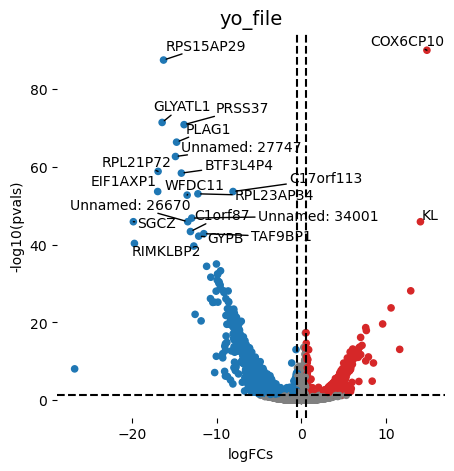

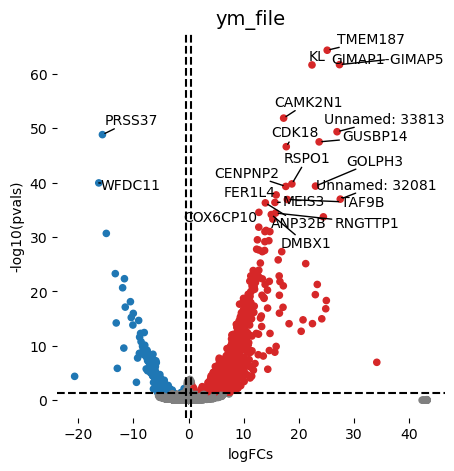

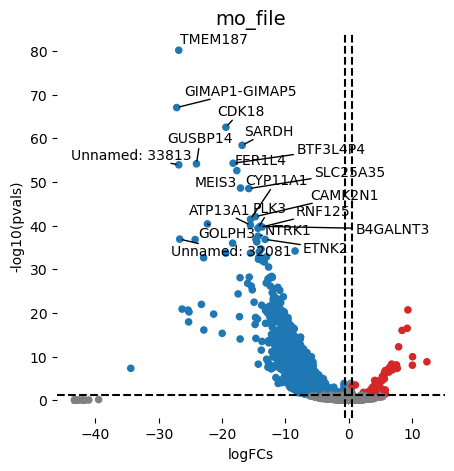

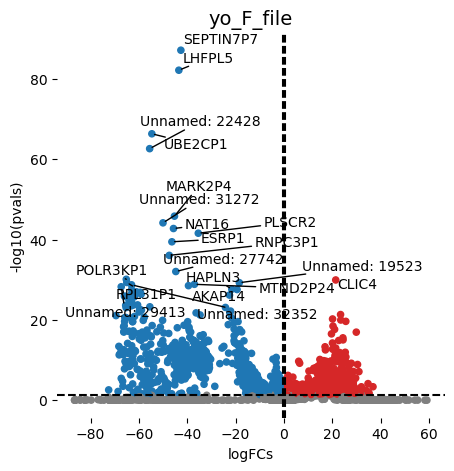

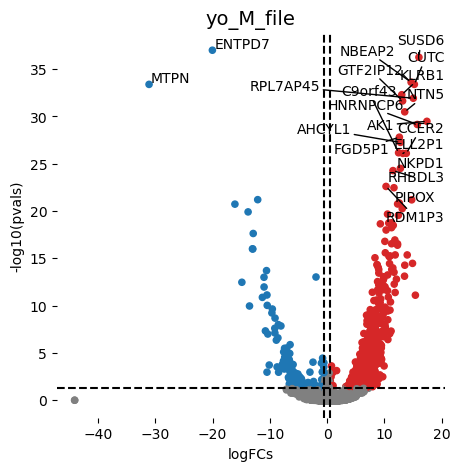

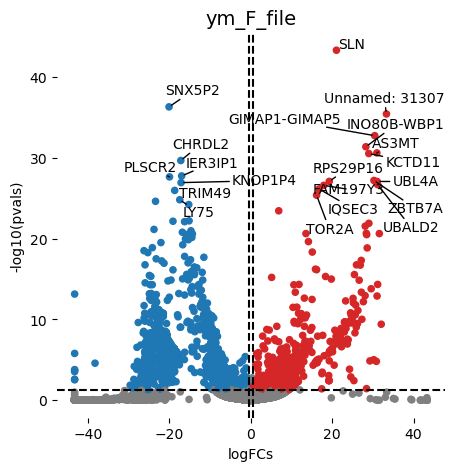

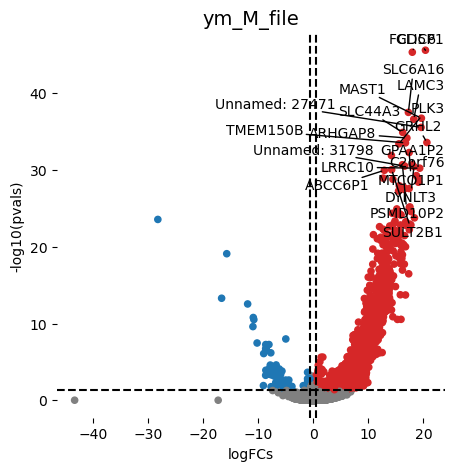

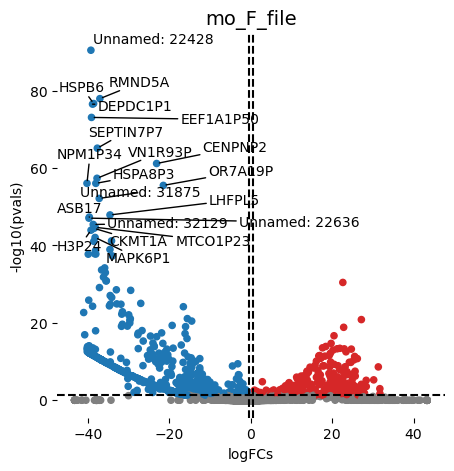

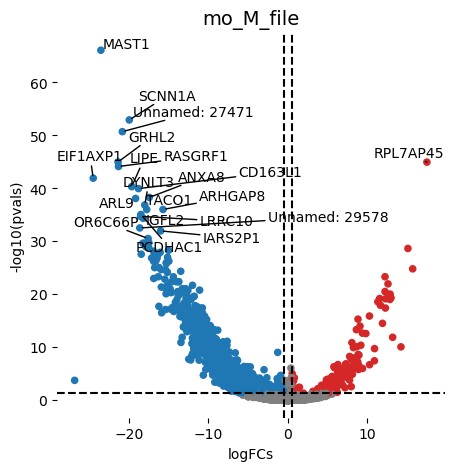

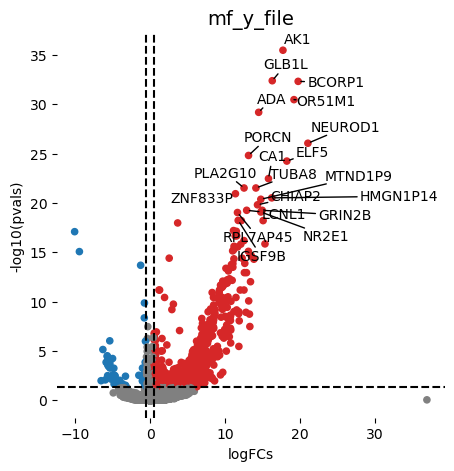

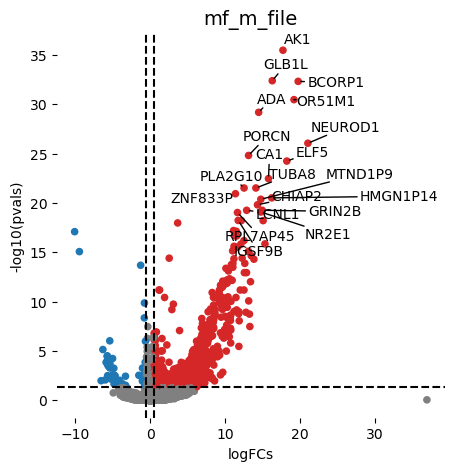

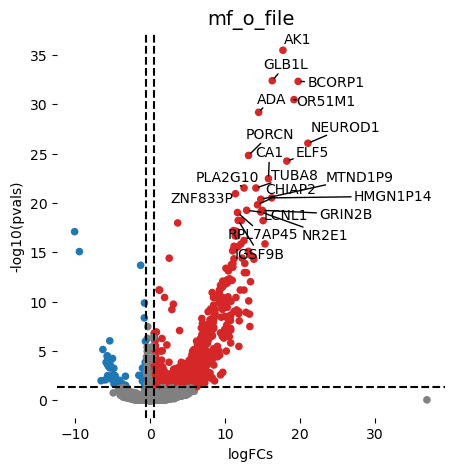

In [14]:
for dds, df in df_dds_dict.items():
    plot_personalize_volcano(df, title=dds)

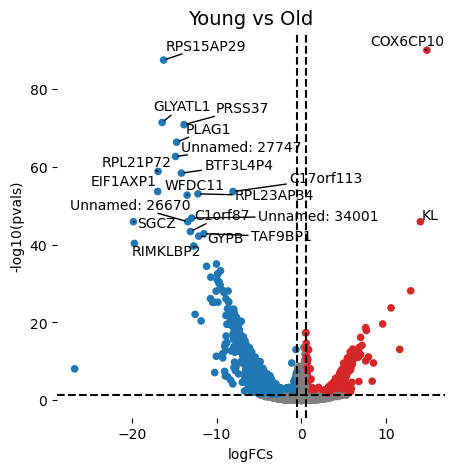

In [14]:
volc_yo= plot_personalize_volcano(yo_df, title="Young vs Old")

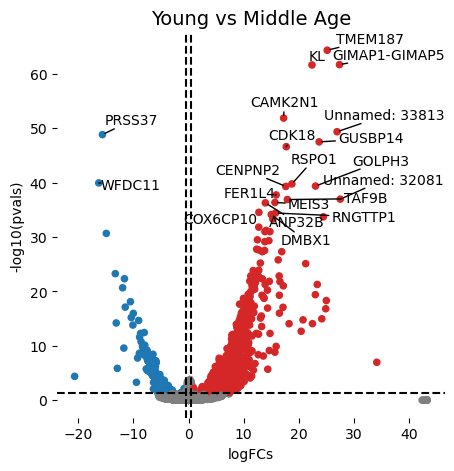

In [15]:
volc_ym= plot_personalize_volcano(ym_df, title="Young vs Middle Age")

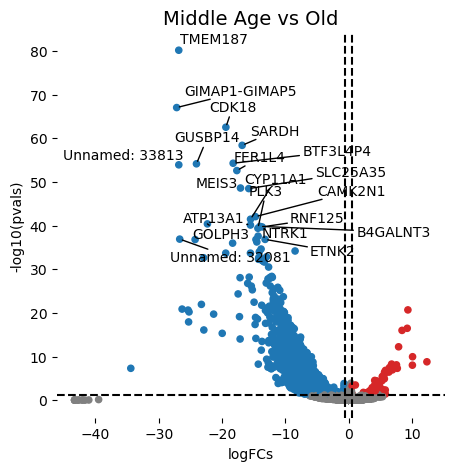

In [16]:
volc_mo= plot_personalize_volcano(mo_df, title="Middle Age vs Old")

In [17]:
volc_yo[0].savefig("results/volcano_plot_yo.png")
volc_mo[0].savefig("results/volcano_plot_mo.png")
volc_ym[0].savefig("results/volcano_plot_ym.png")